# Notebook 2: Graph Construction

**Objectives:**
- Preprocess the Elliptic dataset
- Build a PyG `Data` object
- Create stratified train / val / test masks
- Save graph tensors to disk for reuse

In [1]:
import sys, os
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt

from data_preprocessing import prepare_elliptic
from graph_builder import build_pyg_graph, add_train_val_test_masks, save_graph
from utils import set_seed, class_distribution, plot_class_distribution

set_seed(42)
%matplotlib inline

## 1. Load and Preprocess Data

In [2]:
FEATURE_PATH = '../data/raw/elliptic_txs_features.csv'
CLASS_PATH   = '../data/raw/elliptic_txs_classes.csv'
EDGE_PATH    = '../data/raw/elliptic_txs_edgelist.csv'

feature_matrix, edge_index_array, labels = prepare_elliptic(FEATURE_PATH, CLASS_PATH, EDGE_PATH)

print(f'Node feature matrix : {feature_matrix.shape}')
print(f'Edge index array    : {edge_index_array.shape}')
print(f'Labels              : {labels.shape}')

Node feature matrix : (46564, 166)
Edge index array    : (36624, 2)
Labels              : (46564,)


In [3]:
class_distribution(labels)

Class Distribution:
  Licit (0): 42,019 (90.2%)
  Illicit (1): 4,545 (9.8%)


{0: 42019, 1: 4545}

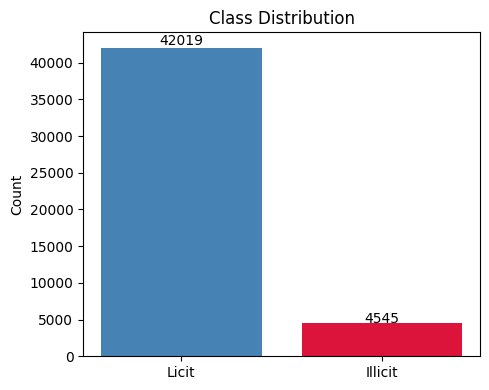

In [4]:
plot_class_distribution(labels, save_path='../results/figures/label_distribution.png')

## 2. Build PyG Data Object

In [5]:
data = build_pyg_graph(feature_matrix, edge_index_array, labels)
print(data)
print(f'Number of nodes   : {data.num_nodes}')
print(f'Number of edges   : {data.num_edges}')
print(f'Number of features: {data.num_features}')
print(f'Is undirected     : {data.is_undirected()}')

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])
Number of nodes   : 46564
Number of edges   : 36624
Number of features: 166
Is undirected     : False


## 3. Train / Val / Test Split

In [6]:
data = add_train_val_test_masks(data, test_size=0.2, val_size=0.2, random_state=42)

print(f'Train nodes : {data.train_mask.sum().item():,}')
print(f'Val nodes   : {data.val_mask.sum().item():,}')
print(f'Test nodes  : {data.test_mask.sum().item():,}')

Train nodes : 29,800
Val nodes   : 7,451
Test nodes  : 9,313


## 4. Verify Masks

Train-Test overlap: 0 (should be 0)


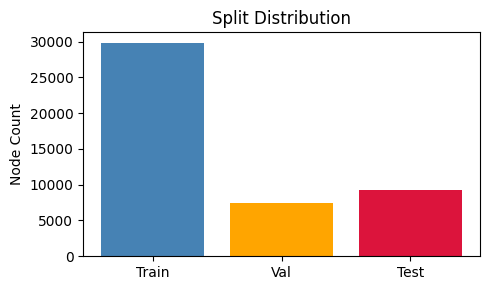

In [7]:
overlap = (data.train_mask & data.test_mask).sum().item()
print(f'Train-Test overlap: {overlap} (should be 0)')

split_labels = ['Train', 'Val', 'Test']
split_counts = [data.train_mask.sum().item(), data.val_mask.sum().item(), data.test_mask.sum().item()]

plt.figure(figsize=(5, 3))
plt.bar(split_labels, split_counts, color=['steelblue','orange','crimson'])
plt.title('Split Distribution')
plt.ylabel('Node Count')
plt.tight_layout()
plt.savefig('../results/figures/split_distribution.png', dpi=150)
plt.show()

## 5. Save Graph to Disk

In [8]:
save_graph(data, '../data/processed')
print('Graph saved successfully.')

Graph saved to ../data/processed/
Graph saved successfully.
